In [59]:
import torch
from torch import nn
import numpy as np
from pandas import read_csv
import matplotlib.pyplot as plt
from reservoirpy.observables import nrmse, rsquare

In [60]:
class testLSTM(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers):
        super(testLSTM, self).__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        y = self.rnn(x)[0]
        seq_len, batch_size, hid_dim = y.shape
        y = y.view(-1, hid_dim)
        y = self.net(y)
        y = y.view(seq_len, batch_size, -1)
        return y

In [61]:
def minmaxscaler(x):
    minx = np.amin(x)
    maxx = np.amax(x)
    return (x-minx)/(maxx-minx), (minx, maxx)

def preminmaxscaler(x, minx, maxx):
    return (x-minx)/(maxx-minx)

def unminmaxscaler(x, minx, maxx):
    return x*(maxx-minx) + minx

In [62]:
data_time = read_csv('../Dataset/Lorenz_data.csv', usecols=[0])
time = data_time.values
time = time.astype('float32')

data_Lorenz = read_csv('../Dataset/Qi_data.csv', usecols=[1, 2, 3])
data_Lorenz = data_Lorenz.values
data_Lorenz = data_Lorenz.astype('float32')

data_x = data_Lorenz[:-1, :]
data_y = data_Lorenz[+1:, :]
print(data_x.shape)

train_size = 4000
train_x = data_x[:train_size, :]
train_y = data_y[:train_size, :]

train_x, train_x_minmax = minmaxscaler(train_x)
train_y, train_y_minmax = minmaxscaler(train_y)

batch_x = train_x[:, np.newaxis, :]
batch_y = train_y[:, np.newaxis, :]
batch_x = torch.tensor(batch_x, dtype=torch.float32)
batch_y = torch.tensor(batch_y, dtype=torch.float32)

# data_Lorenz = data_Lorenz.reshape((data_Lorenz.shape[0], 1, -1))
# print(data_Lorenz.shape)

(4999, 3)


In [63]:
model = testLSTM(input_dim=3, output_dim=3, hidden_dim=16, num_layers=1)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print("Training...................")

for e in range(401):
    out = model(batch_x)
    Loss = loss(out, batch_y)
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()

    if e % 10 == 0:
        print(f'Epoch {e}, Loss:{Loss.item()}')

torch.save(model.state_dict(), './model/net.pth')
print('save in: ./model/net.pth')

Training...................
Epoch 0, Loss:0.3921629786491394
Epoch 10, Loss:0.04794112592935562
Epoch 20, Loss:0.02479667216539383
Epoch 30, Loss:0.019725631922483444
Epoch 40, Loss:0.013775540515780449
Epoch 50, Loss:0.008713691495358944
Epoch 60, Loss:0.007391424849629402
Epoch 70, Loss:0.006591773126274347
Epoch 80, Loss:0.00600300682708621
Epoch 90, Loss:0.005527351517230272
Epoch 100, Loss:0.00502921873703599
Epoch 110, Loss:0.004398238379508257
Epoch 120, Loss:0.0034974899608641863
Epoch 130, Loss:0.0023144346196204424
Epoch 140, Loss:0.0015101927565410733
Epoch 150, Loss:0.001195132383145392
Epoch 160, Loss:0.000960079487413168
Epoch 170, Loss:0.0008322579087689519
Epoch 180, Loss:0.0007339448784478009
Epoch 190, Loss:0.0006552515551447868
Epoch 200, Loss:0.0005830181180499494
Epoch 210, Loss:0.0005143582238815725
Epoch 220, Loss:0.0004483228549361229
Epoch 230, Loss:0.000387337408028543
Epoch 240, Loss:0.00033388359588570893
Epoch 250, Loss:0.0002879567618947476
Epoch 260, Loss

In [64]:
new_data_x = data_x.copy()
new_data_x[train_size:] = 0
test_len = 500

test_x = data_x[train_size:-test_len]
test_y = data_x[train_size+test_len:]

test_x = test_x.reshape((test_x.shape[0], 1, -1))
# test_y = test_y.reshape((test_y.shape[0], 1, -1))

test_x = preminmaxscaler(test_x, train_x_minmax[0], train_x_minmax[1])
batch_test_x = torch.tensor(test_x, dtype=torch.float32)

predict_y = model(batch_test_x)
predict_y = predict_y.detach().numpy()

predict_y = unminmaxscaler(predict_y, train_x_minmax[0], train_x_minmax[1])
predict_y = predict_y.reshape((predict_y.shape[0], -1))
# print(predict_y.shape)

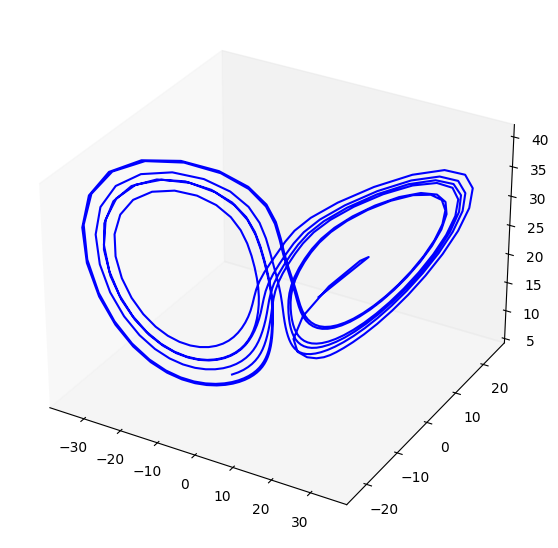

In [65]:
fig = plt.figure(figsize=(15, 10))
# ax  = fig.add_subplot(122, projection='3d')
# ax.plot(test_y[:, 0], test_y[:, 1], test_y[:, 2], c='r')
# ax.grid(False)

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(predict_y[:, 0], predict_y[:, 1], predict_y[:, 2], c='b')
ax1.grid(False)



In [66]:
print(f'r^2={rsquare(test_y, predict_y)}, nrmse={nrmse(test_y, predict_y)}')
# test_y.shape, predict_y.shape

r^2=-0.03874552249908447, nrmse=0.1966807821402537
